#qwen_works.ipynb

vllm works in colab cli
need a100

In [1]:
from google.colab import drive
drive.mount('/content/drive')


ModuleNotFoundError: No module named 'google.colab'

In [ ]:
%cd /content/drive/MyDrive/'Colab Notebooks'
import os
print(os.listdir())

/content/drive/MyDrive/Colab Notebooks
['videos', 'logs', 'ant_rl_v1.ipynb', 'Untitled0.ipynb', 'miniwob_checkpoints', 'browser_gym_server.py', 'mlp_viz_and_robot_arm.ipynb', '.ssh', 'serve_qwen.ipynb', 'qwen_vllm_nowork.ipynb', '.cache', 'qwen_works.ipynb']


In [ ]:
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.ssh /content/
print(os.listdir('/content/.ssh'))

['id_rsa', 'id_rsa.pub']


In [ ]:
#copy the hf models to /content/.cache. they should be in /root/.cache but
# dont overwrite anything in /root
%cp -r /content/drive/MyDrive/'Colab Notebooks'/.cache /content/
print(".cache is in /content, copy to /root/.cache if you want to use deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B ")

In [ ]:
!pip -q install -U vllm
!pip -q install -U "transformers<5" tokenizers accelerate
!python -c "import vllm, transformers, tokenizers; print('vllm', vllm.__version__, 'tf', transformers.__version__, 'tok', tokenizers.__version__)"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 110.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 

In [ ]:
from vllm import LLM, SamplingParams

model_id = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"  # or any supported HF model

llm = LLM(
    model=model_id,
    dtype="float16",
    max_model_len=2048,     # keep small first
    enforce_eager=True,     # avoids CUDA graphs surprises/memory spikes
    gpu_memory_utilization=0.7,
    trust_remote_code=True, # only if required by the model
)

prompts = ["Hello, my name is", "The capital of France is"]
sp = SamplingParams(temperature=0.2, top_p=0.95, max_tokens=64)

outs = llm.generate(prompts, sp)
print(f"type(outs):{type(outs)}")
#process the 2 queries in outs
for o in outs:
    print(o.prompt, "->", o.outputs[0].text)

ModuleNotFoundError: No module named 'vllm'

In [1]:
!pip install vllm transformers psutil requests pandas matplotlib nvidia-ml-py3 --quiet

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.3/508.3 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.6/192.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 158.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 134.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.7/124.7 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 114.2 MB/s eta 0:00:00
   ━━

In [ ]:
import time
import psutil
import requests
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import nvidia_smi  # For GPU metrics

nvidia_smi.nvmlInit()
handle = nvidia_smi.nvmlDeviceGetHandleByIndex(0)

def get_gpu_metrics():
    mem_info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
    util = nvidia_smi.nvmlDeviceGetUtilizationRates(handle)
    return {
        "gpu_util_%": util.gpu,
        "gpu_mem_used_mb": mem_info.used / 1e6
    }

process = psutil.Process()

def get_system_metrics():
    gpu = get_gpu_metrics()
    return {
        "gpu_util_%": gpu["gpu_util_%"],
        "gpu_mem_mb": round(gpu["gpu_mem_used_mb"], 1),
        "cpu_%": round(process.cpu_percent(0.1), 1),
        "ram_mb": round(process.memory_info().rss / 1e6, 1)
    }

prompt = "Explain large language models in simple terms in 3 sentences."
model_name = "Qwen/Qwen2-1.5B-Instruct"  # Open-source, fits T4 GPU, good quality

In [ ]:
#need native_results to compare vs vllm
from transformers import pipeline

print("Loading model with Hugging Face pipeline on GPU...")
start_load = time.time()
generator = pipeline("text-generation", model=model_name, device=0, torch_dtype="auto")
load_time = time.time() - start_load
print(f"HF load time: {load_time:.1f} seconds")

# Single inference
start = time.time()
_ = generator(prompt, max_new_tokens=100, do_sample=True, temperature=0.7)
single_latency = time.time() - start
print(f"HF single inference: {single_latency:.1f} seconds")

# Concurrent inferences (4 users)
def naive_generate(p):
    result = generator(p, max_new_tokens=100, do_sample=True, temperature=0.7)[0]["generated_text"]
    print(result)
    return result

naive_results = []
print("\nHF concurrent tests...")
# this takes a long time.
for users in [1, 4, 8, 16, 32, 100]:
    start = time.time()
    with ThreadPoolExecutor(max_workers=users) as executor:
        list(executor.map(naive_generate, [prompt] * users))
    latency = time.time() - start
    metrics = get_system_metrics()
    naive_results.append({"users": users, "latency_sec": round(latency, 1), "type": "Naïve HF", **metrics})
    print(f"  {users} users → {latency:.1f} seconds, GPU util: {metrics['gpu_util_%']}%, GPU mem: {metrics['gpu_mem_mb']} MB")

pd.DataFrame(naive_results)

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cuda:0


HF load time: 4.3 seconds
HF single inference: 4.3 seconds

HF concurrent tests...
Explain large language models in simple terms in 3 sentences. Large language models are sophisticated artificial intelligence systems that can understand and generate human-like text, such as writing stories or generating code. They use algorithms to analyze vast amounts of data and learn from it, allowing them to create content that is coherent, contextually appropriate, and engaging for humans.

These models have become increasingly important in various fields, including natural language processing (NLP), machine translation, chatbots, and more. They enable machines to perform tasks that were previously considered too complex or impossible for computers
  1 users → 3.5 seconds, GPU util: 28%, GPU mem: 15365.2 MB
Explain large language models in simple terms in 3 sentences. Large language models are computer programs that can understand and generate human-like text based on input data. They use algorith

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Explain large language models in simple terms in 3 sentences. Large language models are complex AI systems that can understand and generate human-like text, such as writing stories, poems, or even answering questions. They use algorithms to analyze vast amounts of data from the internet, books, and other sources to learn patterns and relationships between words, phrases, and concepts.

These models have become increasingly sophisticated over time, allowing them to generate highly accurate and natural-sounding responses, often surpassing human abilities in certain tasks like translation, summarization, and question answering. However,
Explain large language models in simple terms in 3 sentences. Large language models are computer programs that can understand and generate human-like text based on input data. They use advanced algorithms to analyze vast amounts of text data, including books, articles, and social media posts, to learn patterns and relationships between words and phrases. T

,users,latency_sec,type,gpu_util_%,gpu_mem_mb,cpu_%,ram_mb
0,1,3.5,Naïve HF,28,15365.2,0.0,2682.6
1,4,11.0,Naïve HF,36,15444.9,0.0,2684.0
2,8,36.9,Naïve HF,26,15545.5,0.0,2685.8
3,16,85.2,Naïve HF,19,15755.2,0.0,2689.5
4,32,160.2,Naïve HF,20,16139.0,0.0,2696.6
5,100,523.6,Naïve HF,20,17862.9,0.0,2725.9


In [2]:
!pkill -f vllm || true

import time
time.sleep(2)

model_name = "Qwen/Qwen2-1.5B-Instruct"  # Open-source, fits T4 GPU, good quality
#   --gpu-memory-utilization 0.50 too high. vllm tries to reserve 50% of gpu memory, 11G in L4


# Start server in background with separate stdout/stderr logs
# this is better bc you can tail log.err and figure out if the safetensors are
# loaded yet. this tells you if the model is ready to start serving
!nohup python -m vllm.entrypoints.openai.api_server \
  --model Qwen/Qwen2-1.5B-Instruct \
  --dtype auto \
  --gpu-memory-utilization 0.25 \
  --max-model-len 2048 \
  --max-num-seqs 8 \
  --port 8000 \
  > /content/log.out 2> /content/log.err &

print("Server starting... wait 1-2 min for model load.")
time.sleep(10)  # Initial wait
#log.out should look like this:
#(EngineCore_DP0 pid=34352) INFO 03-03 23:19:48 [weight_utils.py:579] No model.safetensors.index.json found in remote.
#(EngineCore_DP0 pid=34352) INFO 03-03 23:19:49 [default_loader.py:293] Loading weights took 1.03 seconds
#(EngineCore_DP0 pid=34352) INFO 03-03 23:19:50 [gpu_model_runner.py:4221] Model loading took 2.89 GiB memory and 3.297181 seconds

^C
Server starting... wait 1-2 min for model load.


use tail log.out to verify the model loading is complete

```
APIServer pid=3029) INFO 03-03 23:29:57 [vllm.py:689] Asynchronous scheduling is enabled.
(EngineCore_DP0 pid=3337) INFO 03-03 23:30:15 [core.py:97] Initializing a V1 LLM engine (v0.16.0) with config: model='Qwen/Qwen2-1.5B-Instruct', speculative_config=None, tokenizer='Qwen/Qwen2-1.5B-Instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=2048, download_dir=None, load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, disable_custom_all_reduce=False, quantization=None, enforce_eager=False, enable_return_routed_experts=False, kv_cache_dtype=auto, device_config=cuda, structured_outputs_config=StructuredOutputsConfig(backend='auto', disable_fallback=False, disable_any_whitespace=False, disable_additional_properties=False, reasoning_parser='', reasoning_parser_plugin='', enable_in_reasoning=False), observability_config=ObservabilityConfig(show_hidden_metrics_for_version=None, otlp_traces_endpoint=None, collect_detailed_traces=None, kv_cache_metrics=False, kv_cache_metrics_sample=0.01, cudagraph_metrics=False, enable_layerwise_nvtx_tracing=False, enable_mfu_metrics=False, enable_mm_processor_stats=False, enable_logging_iteration_details=False), seed=0, served_model_name=Qwen/Qwen2-1.5B-Instruct, enable_prefix_caching=True, enable_chunked_prefill=True, pooler_config=None, compilation_config={'level': None, 'mode': <CompilationMode.VLLM_COMPILE: 3>, 'debug_dump_path': None, 'cache_dir': '', 'compile_cache_save_format': 'binary', 'backend': 'inductor', 'custom_ops': ['none'], 'splitting_ops': ['vllm::unified_attention', 'vllm::unified_attention_with_output', 'vllm::unified_mla_attention', 'vllm::unified_mla_attention_with_output', 'vllm::mamba_mixer2', 'vllm::mamba_mixer', 'vllm::short_conv', 'vllm::linear_attention', 'vllm::plamo2_mamba_mixer', 'vllm::gdn_attention_core', 'vllm::kda_attention', 'vllm::sparse_attn_indexer', 'vllm::rocm_aiter_sparse_attn_indexer', 'vllm::unified_kv_cache_update'], 'compile_mm_encoder': False, 'compile_sizes': [], 'compile_ranges_split_points': [2048], 'inductor_compile_config': {'enable_auto_functionalized_v2': False, 'combo_kernels': True, 'benchmark_combo_kernel': True}, 'inductor_passes': {}, 'cudagraph_mode': <CUDAGraphMode.FULL_AND_PIECEWISE: (2, 1)>, 'cudagraph_num_of_warmups': 1, 'cudagraph_capture_sizes': [1, 2, 4, 8, 16], 'cudagraph_copy_inputs': False, 'cudagraph_specialize_lora': True, 'use_inductor_graph_partition': False, 'pass_config': {'fuse_norm_quant': False, 'fuse_act_quant': False, 'fuse_attn_quant': False, 'eliminate_noops': True, 'enable_sp': False, 'fuse_gemm_comms': False, 'fuse_allreduce_rms': False, 'fuse_act_padding': False}, 'max_cudagraph_capture_size': 16, 'dynamic_shapes_config': {'type': <DynamicShapesType.BACKED: 'backed'>, 'evaluate_guards': False, 'assume_32_bit_indexing': False}, 'local_cache_dir': None, 'fast_moe_cold_start': True, 'static_all_moe_layers': []}
(EngineCore_DP0 pid=3337) INFO 03-03 23:30:17 [parallel_state.py:1234] world_size=1 rank=0 local_rank=0 distributed_init_method=tcp://172.28.0.12:39375 backend=nccl
(EngineCore_DP0 pid=3337) INFO 03-03 23:30:17 [parallel_state.py:1445] rank 0 in world size 1 is assigned as DP rank 0, PP rank 0, PCP rank 0, TP rank 0, EP rank N/A
(EngineCore_DP0 pid=3337) INFO 03-03 23:30:18 [gpu_model_runner.py:4124] Starting to load model Qwen/Qwen2-1.5B-Instruct...



```

```
APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /ping, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /invocations, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/chat/completions, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/chat/completions/render, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/responses, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/responses/{response_id}, Methods: GET
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/responses/{response_id}/cancel, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/completions, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/completions/render, Methods: POST
(APIServer pid=3029) INFO 03-03 23:31:37 [launcher.py:47] Route: /v1/messages, Methods: POST

```

If you dont see the messagaes above before running cell below, vllm server wont work

In [3]:
!pip -q install requests

import sys, time, subprocess, requests

url = "http://127.0.0.1:8000/health"

for i in range(2):  # up to ~60 tries
    try:
        r = requests.get(url, timeout=2)
        if r.status_code == 200:
            print("✅ vLLM server is ready!")
            break
        else:
            print(f"Attempt {i+1}: status={r.status_code}")
    except Exception as e:
        print(f"Attempt {i+1}: not ready ({e})")
time.sleep(2)


✅ vLLM server is ready!


In [ ]:
import time
import psutil
import requests
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ThreadPoolExecutor
import nvidia_smi  # For GPU metrics

nvidia_smi.nvmlInit()
handle = nvidia_smi.nvmlDeviceGetHandleByIndex(0)

def get_gpu_metrics():
    mem_info = nvidia_smi.nvmlDeviceGetMemoryInfo(handle)
    util = nvidia_smi.nvmlDeviceGetUtilizationRates(handle)
    return {
        "gpu_util_%": util.gpu,
        "gpu_mem_used_mb": mem_info.used / 1e6
    }

process = psutil.Process()

def get_system_metrics():
    gpu = get_gpu_metrics()
    return {
        "gpu_util_%": gpu["gpu_util_%"],
        "gpu_mem_mb": round(gpu["gpu_mem_used_mb"], 1),
        "cpu_%": round(process.cpu_percent(0.1), 1),
        "ram_mb": round(process.memory_info().rss / 1e6, 1)
    }

prompt = "Explain large language models in simple terms in 3 sentences."
model_name = "Qwen/Qwen2-1.5B-Instruct"  # Open-source, fits T4 GPU, good quality



print("vLLM load time: Model already loaded in server (fast startup in production)")
prompt = "Explain large language models in simple terms in 3 sentences."
# Single inference with vLLM
start = time.time()
r = requests.post(
    "http://localhost:8000/v1/completions",
    json={"model": model_name, "prompt": prompt, "max_tokens": 100, "temperature": 0.7},
    timeout=60
)
single_latency = time.time() - start
print(f"vLLM single inference: {single_latency:.1f} seconds")

# Concurrent inferences
def vllm_generate(p):
    r = requests.post(
        "http://localhost:8000/v1/completions",
        json={"model": model_name, "prompt": p, "max_tokens": 100, "temperature": 0.7},
        timeout=60
    )
    result = r.json()["choices"][0]["text"]
    print(result)
    return result
from concurrent.futures import ThreadPoolExecutor, as_completed
vllm_results = []
print("\nvLLM concurrent tests...")
for users in [1, 4, 8, 16, 32, 100]:
    start = time.time()
    with ThreadPoolExecutor(max_workers=users) as executor:
        list(executor.map(vllm_generate, [prompt] * users))
    latency = time.time() - start
    metrics = get_system_metrics()
    vllm_results.append({"users": users, "latency_sec": round(latency, 1), "type": "vLLM", **metrics})
    print(f"  {users} users → {latency:.1f} seconds, GPU util: {metrics['gpu_util_%']}%, GPU mem: {metrics['gpu_mem_mb']} MB")

print(pd.DataFrame(vllm_results))


vLLM load time: Model already loaded in server (fast startup in production)
vLLM single inference: 0.5 seconds

vLLM concurrent tests...
 Large language models are sophisticated computer programs that can understand and generate human-like text, such as writing stories or generating code. They are trained on vast amounts of text data to learn patterns and relationships between words, enabling them to produce coherent and meaningful text that is indistinguishable from human-generated content.

These models are used for a wide range of applications, including natural language processing (NLP), machine translation, speech recognition, and chatbots. They have revolutionized fields like AI research, content creation,
  1 users → 0.5 seconds, GPU util: 99%, GPU mem: 11499.3 MB
 Large language models are complex AI systems designed to understand and generate human language, such as text or speech. They can be trained on vast amounts of data, learn from it, and adapt their responses accordingl

,users,latency_sec,type,gpu_util_%,gpu_mem_mb,cpu_%,ram_mb
0,1,3.5,Naïve HF,28,15365.2,0.0,2682.6
1,4,11.0,Naïve HF,36,15444.9,0.0,2684.0
2,8,36.9,Naïve HF,26,15545.5,0.0,2685.8
3,16,85.2,Naïve HF,19,15755.2,0.0,2689.5
4,32,160.2,Naïve HF,20,16139.0,0.0,2696.6
5,100,523.6,Naïve HF,20,17862.9,0.0,2725.9
6,1,0.5,vLLM,99,11499.3,0.0,215.1
7,4,0.5,vLLM,99,11499.3,0.0,215.3
8,8,0.5,vLLM,99,11499.3,0.0,215.5
9,16,1.2,vLLM,99,11499.3,0.0,215.9


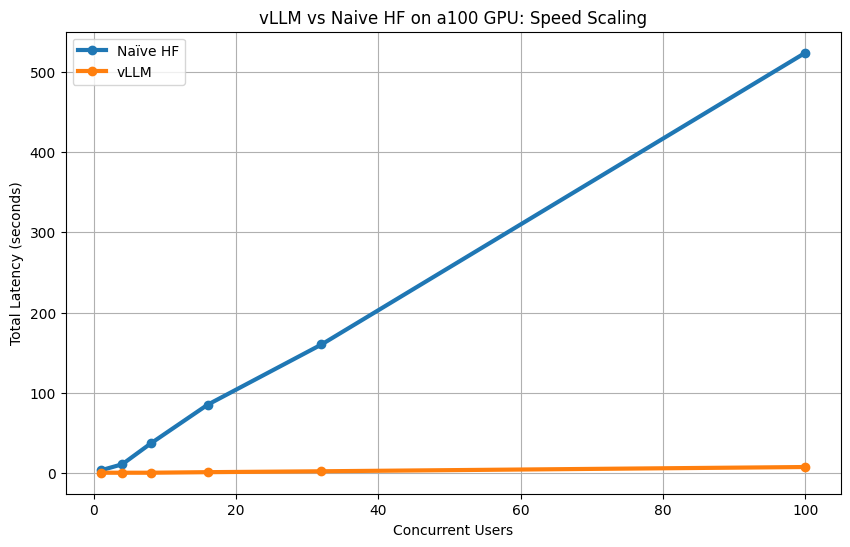

In [ ]:
df = pd.DataFrame(naive_results + vllm_results)
display(df)

plt.figure(figsize=(10, 6))
for typ in ['Naïve HF', 'vLLM']:
    sub = df[df['type'] == typ]
    plt.plot(sub['users'], sub['latency_sec'], label=typ, marker='o', linewidth=3)
plt.xlabel('Concurrent Users')
plt.ylabel('Total Latency (seconds)')
plt.title('vLLM vs Naive HF on a100 GPU: Speed Scaling')
plt.legend()
plt.grid(True)
plt.show()